In [9]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np

import os
import sys
# Add the parent directory to the system path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils.raven_utils import remove_out_of_order

In [7]:
raven_csv_file = '../data/Final Raven Data/Peg_Transfer_S01_T03.csv'
trakstar_csv_file = '../data/Synchronized trakStar Kinematic Data/Peg_Transfer_S01_T03_trakStar_synced.csv'


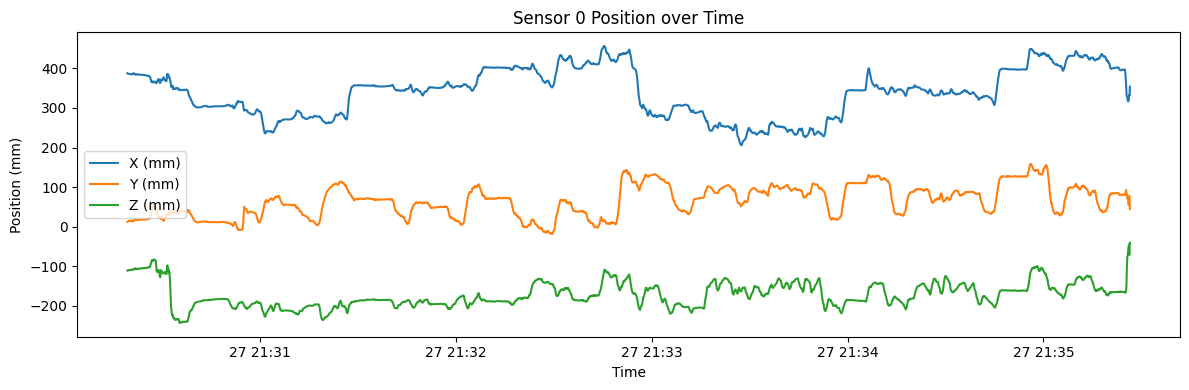

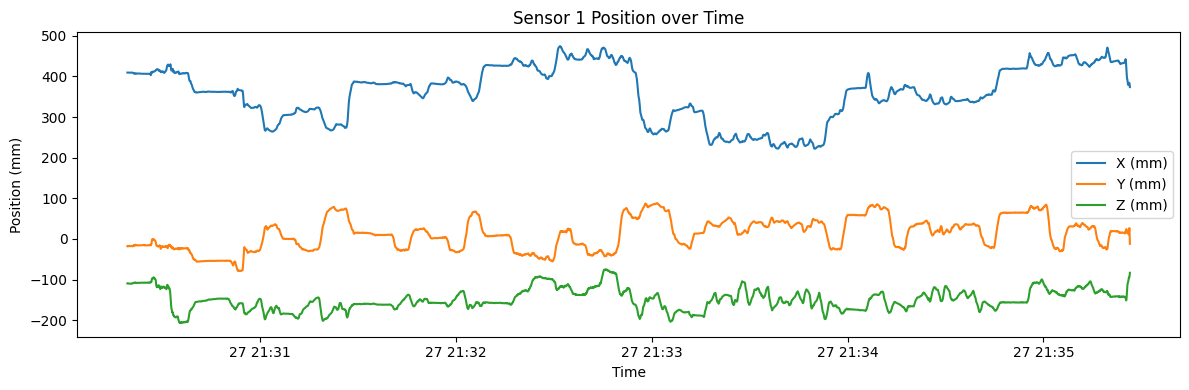

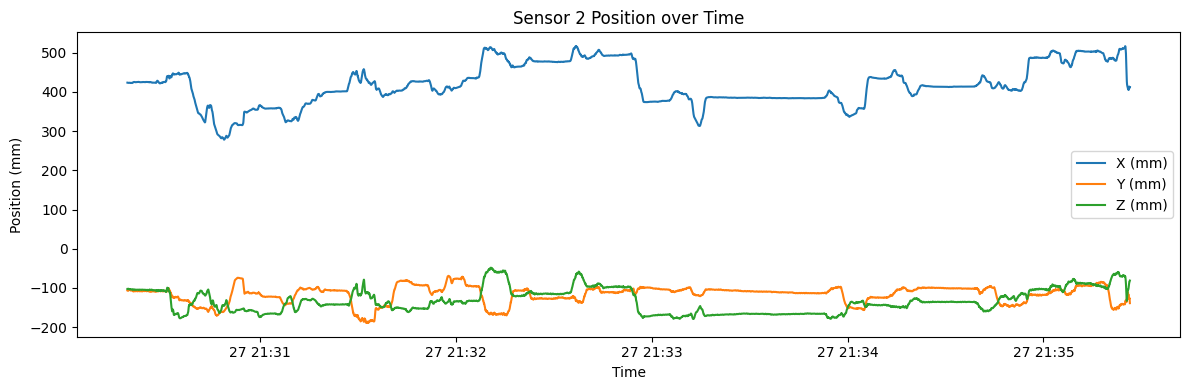

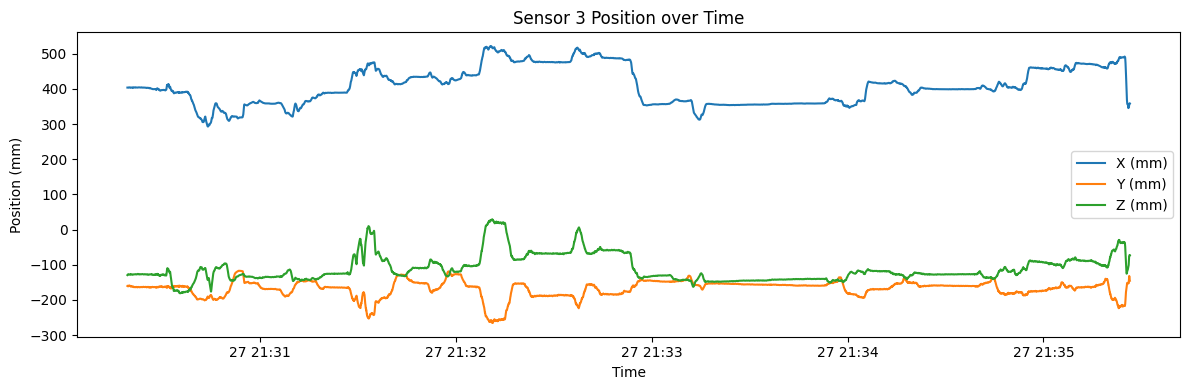

In [10]:


# Load the data
df = pd.read_csv(trakstar_csv_file)
df = remove_out_of_order(df, 'Frame Timestamp')

# Convert 'Frame Timestamp' (ms since epoch) to datetime
df['Frame Timestamp'] = pd.to_datetime(df['Frame Timestamp'], unit='ms')

# List of sensor IDs
sensor_ids = df['Sensor ID'].unique()

# Loop for Position (X, Y, Z) plots
for sensor_id in sensor_ids:
    sensor_df = df[df['Sensor ID'] == sensor_id]
    plt.figure(figsize=(12, 4))
    plt.plot(sensor_df['Frame Timestamp'], sensor_df['X (mm)'], label='X (mm)')
    plt.plot(sensor_df['Frame Timestamp'], sensor_df['Y (mm)'], label='Y (mm)')
    plt.plot(sensor_df['Frame Timestamp'], sensor_df['Z (mm)'], label='Z (mm)')
    plt.ylabel('Position (mm)')
    plt.xlabel('Time')
    plt.title(f'Sensor {sensor_id} Position over Time')
    plt.legend()
    plt.tight_layout()
    plt.show()

# # Loop for Orientation (Azimuth, Elevation, Roll) plots
# for sensor_id in sensor_ids:
#     sensor_df = df[df['Sensor ID'] == sensor_id]
#     plt.figure(figsize=(12, 4))
#     plt.plot(sensor_df['Frame Timestamp'], sensor_df['Azimuth'], label='Azimuth')
#     plt.plot(sensor_df['Frame Timestamp'], sensor_df['Elevation'], label='Elevation')
#     plt.plot(sensor_df['Frame Timestamp'], sensor_df['Roll'], label='Roll')
#     plt.ylabel('Orientation (degrees)')
#     plt.xlabel('Time')
#     plt.title(f'Sensor {sensor_id} Orientation over Time')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

## Raven Kinematic Visualize PSML and PSMR

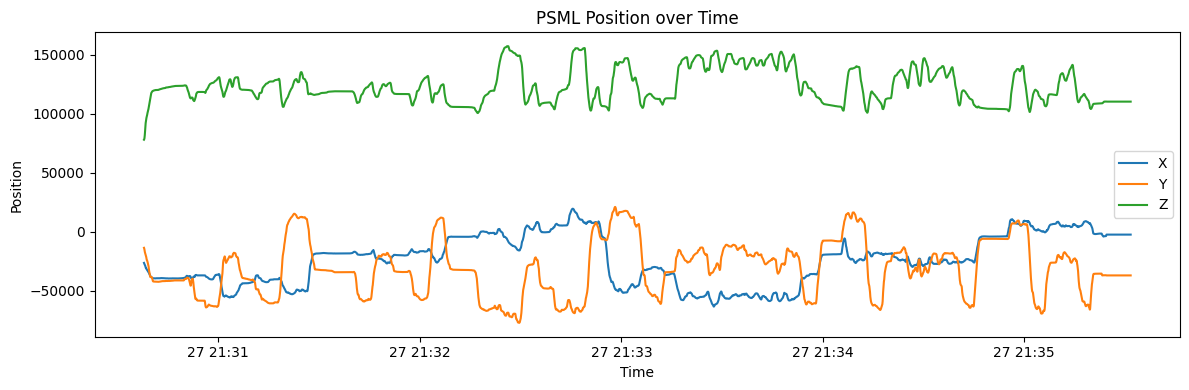

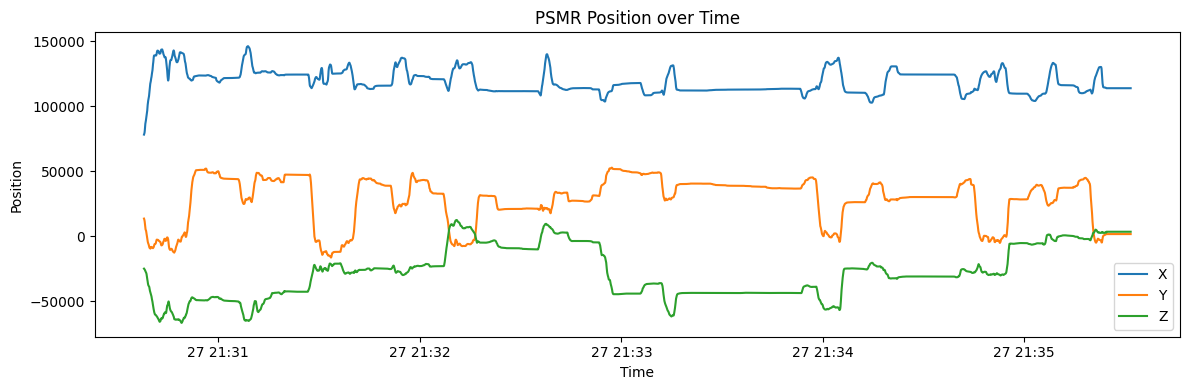

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# ——— Load your CSV ———
df = pd.read_csv(raven_csv_file)


# ——— Convert millisecond timestamps to datetime ———
df['Time'] = pd.to_datetime(df['Timestamp'], unit='ms')

# ——— Define the two “sensors” and their XYZ columns ———
sensors = {
    'PSML': ('PSML_position_x', 'PSML_position_y', 'PSML_position_z'),
    'PSMR': ('PSMR_position_x', 'PSMR_position_y', 'PSMR_position_z'),
}

# ——— Loop #1: Plot X/Y/Z for PSML ———
for name, (cx, cy, cz) in sensors.items():
    plt.figure(figsize=(12, 4))
    plt.plot(df['Time'], df[cx], label='X')
    plt.plot(df['Time'], df[cy], label='Y')
    plt.plot(df['Time'], df[cz], label='Z')
    plt.xlabel('Time')
    plt.ylabel('Position')
    plt.title(f'{name} Position over Time')
    plt.legend()
    plt.tight_layout()
    plt.show()


# Correlation Study

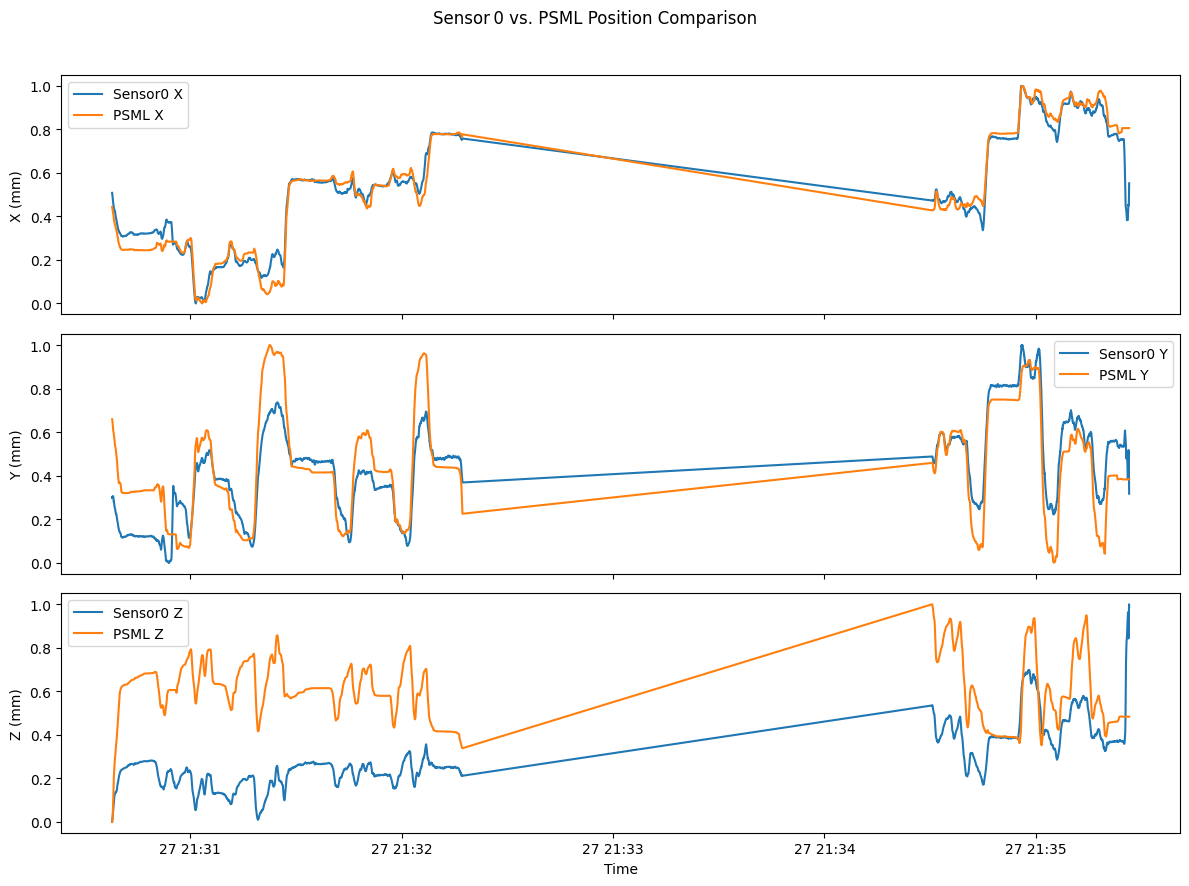

Pearson r (Sensor0 vs PSML) for X: 0.981
Pearson r (Sensor0 vs PSML) for Y: 0.823
Pearson r (Sensor0 vs PSML) for Z: 0.245


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# ——— Load and prepare magnet‐tracker data ———
mag = pd.read_csv(trakstar_csv_file)   # replace with your magnet CSV
mag = remove_out_of_order(mag, 'Frame Timestamp')

mag['Time'] = pd.to_datetime(mag['Frame Timestamp'], unit='ms')

# Filter out Sensor 0 and rename columns
sensor0 = (
    mag[mag['Sensor ID'] == 0]
    .loc[:, ['Time', 'X (mm)', 'Y (mm)', 'Z (mm)']]
    .rename(columns={
        'X (mm)':   'mag_X',
        'Y (mm)':   'mag_Y',
        'Z (mm)':   'mag_Z'
    })
    .sort_values('Time')
)

# ——— Load and prepare PSM data ———
psm = pd.read_csv(raven_csv_file)   # replace with your PSM CSV
psm['Time'] = pd.to_datetime(psm['Timestamp'], unit='ms')

psml = (
    psm.loc[:, ['Time',
                'PSML_position_x', 'PSML_position_y', 'PSML_position_z']]
       .rename(columns={
           'PSML_position_x': 'PSML_X',
           'PSML_position_y': 'PSML_Y',
           'PSML_position_z': 'PSML_Z'
       })
       .sort_values('Time')
)

# ——— Align the two streams by nearest timestamp within 10 ms ———
df = pd.merge_asof(
    sensor0,
    psml,
    on='Time',
    tolerance=pd.Timedelta('10ms'),
    direction='nearest'
).dropna()



# ——— Min–max normalization per axis & sensor ———
for axis in ['X','Y','Z']:
    # sensor0
    col = f'mag_{axis}'
    min0, max0 = df[col].min(), df[col].max()
    df[f'{col}_norm'] = (df[col] - min0) / (max0 - min0)
    # PSML
    col2 = f'PSML_{axis}'
    min1, max1 = df[col2].min(), df[col2].max()
    df[f'{col2}_norm'] = (df[col2] - min1) / (max1 - min1)


# ——— Plotting X, Y, Z over time on the same axes ———
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes = axes.flatten()


for ax, axis in zip(axes, ['X', 'Y', 'Z']):
    ax.plot(df['Time'], df[f'mag_{axis}_norm'], label=f'Sensor0 {axis}')
    ax.plot(df['Time'], df[f'PSML_{axis}_norm'], label=f'PSML {axis}')
    ax.set_ylabel(f'{axis} (mm)')
    ax.legend()
    
axes[-1].set_xlabel('Time')
fig.suptitle('Sensor 0 vs. PSML Position Comparison')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ——— Compute Pearson correlation for each axis ———
for axis in ['X', 'Y', 'Z']:
    r = df[f'mag_{axis}_norm'].corr(df[f'PSML_{axis}_norm'])
    print(f'Pearson r (Sensor0 vs PSML) for {axis}: {r:.3f}')


Best lag: -4 samples ≃ -0.133 s


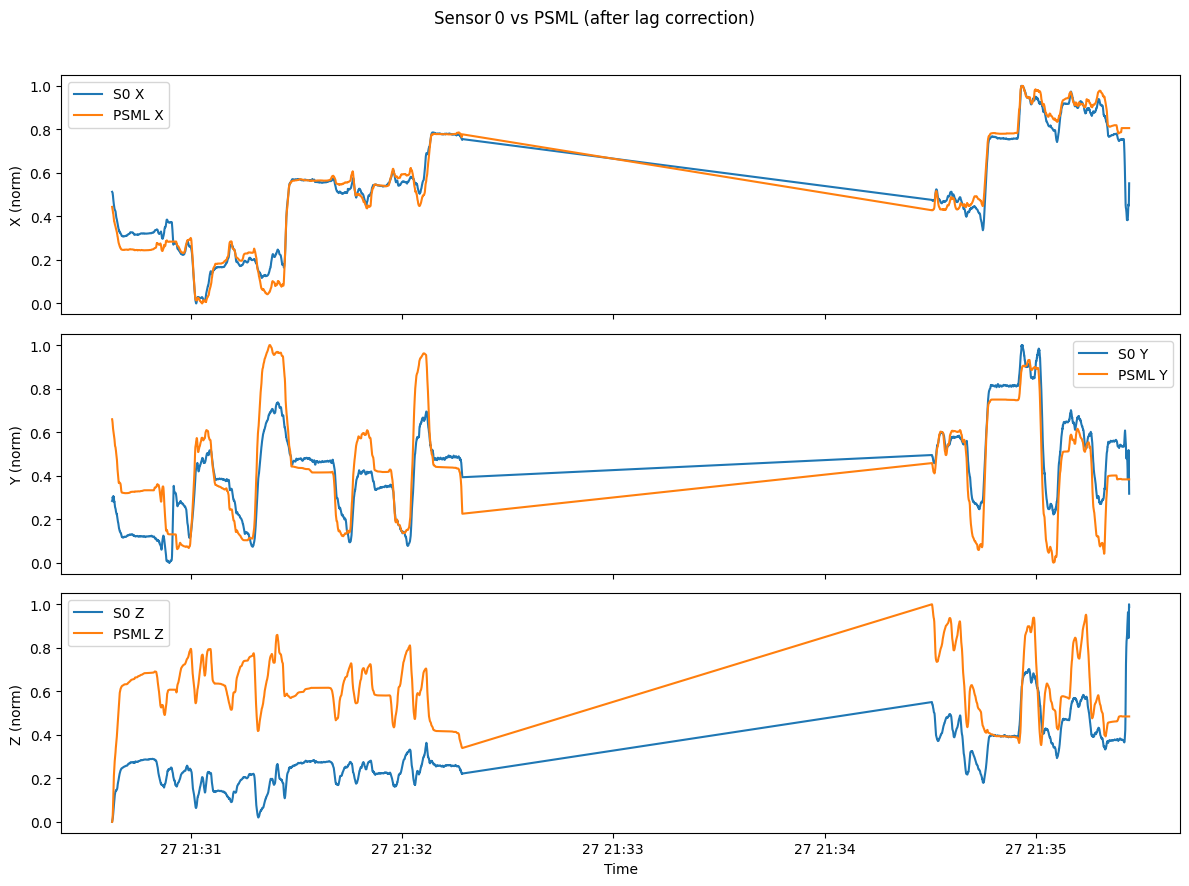

Pearson r (post‑shift) for X: 0.981
Pearson r (post‑shift) for Y: 0.818
Pearson r (post‑shift) for Z: 0.251


In [14]:

# ——— Load and prepare magnet‐tracker data ———
mag = pd.read_csv(trakstar_csv_file)   # replace with your magnet CSV
mag = remove_out_of_order(mag, 'Frame Timestamp')
mag['Time'] = pd.to_datetime(mag['Frame Timestamp'], unit='ms')

# Filter out Sensor 0 and rename columns
sensor0 = (
    mag[mag['Sensor ID'] == 0]
    .loc[:, ['Time', 'X (mm)', 'Y (mm)', 'Z (mm)']]
    .rename(columns={
        'X (mm)':   'mag_X',
        'Y (mm)':   'mag_Y',
        'Z (mm)':   'mag_Z'
    })
    .sort_values('Time')
)

# ——— Load and prepare PSM data ———
psm = pd.read_csv(raven_csv_file)   # replace with your PSM CSV
psm['Time'] = pd.to_datetime(psm['Timestamp'], unit='ms')

psml = (
    psm.loc[:, ['Time',
                'PSML_position_x', 'PSML_position_y', 'PSML_position_z']]
       .rename(columns={
           'PSML_position_x': 'PSML_X',
           'PSML_position_y': 'PSML_Y',
           'PSML_position_z': 'PSML_Z'
       })
       .sort_values('Time')
)

# ——— Align the two streams by nearest timestamp within 10 ms ———
df = pd.merge_asof(
    sensor0,
    psml,
    on='Time',
    tolerance=pd.Timedelta('10ms'),
    direction='nearest'
).dropna()

# min–max normalize each channel
for axis in ['X','Y','Z']:
    a = f'mag_{axis}'; b = f'PSML_{axis}'
    df[f'{a}_n'] = (df[a] - df[a].min()) / (df[a].max() - df[a].min())
    df[f'{b}_n'] = (df[b] - df[b].min()) / (df[b].max() - df[b].min())

# ——— 2) Estimate lag on one axis (e.g. X) —————————————————————————
x1 = df['mag_X_n'].to_numpy()
x2 = df['PSML_X_n'].to_numpy()
corr = np.correlate(x1 - x1.mean(), x2 - x2.mean(), mode='full')
lags = np.arange(-len(x1)+1, len(x1))
best_lag = lags[corr.argmax()]

# compute how many seconds that is
dt = df['Time'].diff().dt.total_seconds().median()  # approx sampling interval (s)
time_offset = best_lag * dt
print(f'Best lag: {best_lag} samples ≃ {time_offset:.3f} s')

# ——— 3) Shift PSML timestamps & re‑align ————————————————————————
psml['Time_shifted'] = psml['Time'] + pd.Timedelta(seconds=time_offset)

df2 = pd.merge_asof(
    sensor0,
    psml[['Time_shifted','PSML_X','PSML_Y','PSML_Z']],
    left_on='Time', right_on='Time_shifted',
    tolerance=pd.Timedelta('10ms'),
    direction='nearest'
).dropna()

# min–max normalize post‑shift
for axis in ['X','Y','Z']:
    mcol = f'mag_{axis}'
    pcol = f'PSML_{axis}'
    df2[f'{mcol}_n'] = (df2[mcol] - df2[mcol].min()) / (df2[mcol].max() - df2[mcol].min())
    df2[f'{pcol}_n'] = (df2[pcol] - df2[pcol].min()) / (df2[pcol].max() - df2[pcol].min())

# ——— 4) Plot & recompute correlations —————————————————————————
fig, axs = plt.subplots(3,1,figsize=(12,9), sharex=True)
for ax, axis in zip(axs, ['X','Y','Z']):
    ax.plot(df2['Time'], df2[f'mag_{axis}_n'], label=f'S0 {axis}')
    ax.plot(df2['Time'], df2[f'PSML_{axis}_n'], label=f'PSML {axis}')
    ax.set_ylabel(f'{axis} (norm)')
    ax.legend()
axs[-1].set_xlabel('Time')
plt.suptitle('Sensor 0 vs PSML (after lag correction)')
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

for axis in ['X','Y','Z']:
    r = df2[f'mag_{axis}_n'].corr(df2[f'PSML_{axis}_n'])
    print(f'Pearson r (post‑shift) for {axis}: {r:.3f}')
